In [46]:
import pandas as pd
import numpy as np
import math
import os
import seaborn as sns
import matplotlib.pyplot as plt
import warnings


In [3]:
import sys
from pathlib import Path
import importlib

sys.path.append(str(Path().resolve().parent))

from src.data_loader import load_raw_data, merge_datasets
import src.data_loader as data_loader
importlib.reload(data_loader)

df_train, df_test, features, stores = data_loader.load_raw_data()

In [4]:
df_train_m = merge_datasets(df_train,features,stores)
df_test_m = merge_datasets(df_test,features,stores)

In [5]:
df_train_m.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [6]:
df_train_m["Date"] = pd.to_datetime(df_train_m["Date"])
df_test_m["Date"] = pd.to_datetime(df_test_m["Date"])

In [7]:
df_train_m.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [8]:
df_train_m.shape

(421570, 16)

In [9]:
df_train_m["Weekly_Sales"].isnull().sum()

np.int64(0)

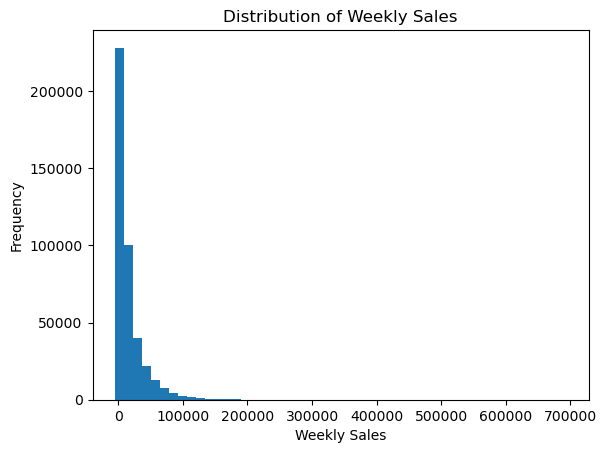

In [10]:
plt.hist(df_train_m["Weekly_Sales"], bins=50)
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.show()

In [11]:
df_train_m = df_train_m[df_train_m["Weekly_Sales"] >= 0].copy()

In [12]:
df_train_m["Weekly_Sales"] = np.log1p(df_train_m["Weekly_Sales"])

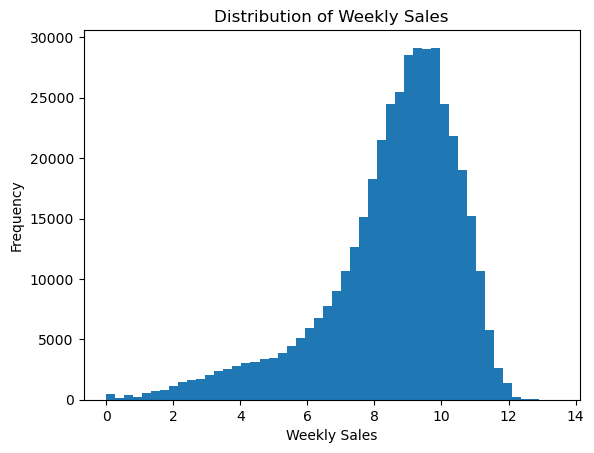

In [13]:
plt.hist(df_train_m["Weekly_Sales"], bins=50)
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.show()

In [14]:
df_train_m = df_train_m.sort_values(["Store", "Dept", "Date"])
df_train_m["lag_1"] = df_train_m.groupby(["Store", "Dept"])["Weekly_Sales"].shift(1)
df_train_m["lag_2"] = df_train_m.groupby(["Store", "Dept"])["Weekly_Sales"].shift(2)
df_train_m["lag_4"] = df_train_m.groupby(["Store", "Dept"])["Weekly_Sales"].shift(4)
df_train_m["rolling_mean_4"] = df_train_m.groupby(["Store", "Dept"])["Weekly_Sales"].shift(1).rolling(4).mean()

In [15]:
df_train_m = df_train_m.dropna(subset=["lag_1", "lag_2", "lag_4", "rolling_mean_4"])

In [16]:
df_train_m.head(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,lag_1,lag_2,lag_4,rolling_mean_4
4,1,1,2010-03-05,9.990990,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315,9.873262,10.635773,10.123647,10.342490
5,1,1,2010-03-12,9.954389,False,57.79,2.667,NaN,NaN,NaN,NaN,NaN,211.380643,8.106,A,151315,9.990990,9.873262,10.737277,10.309325
6,1,1,2010-03-19,10.005035,False,54.58,2.720,NaN,NaN,NaN,NaN,NaN,211.215635,8.106,A,151315,9.954389,9.990990,10.635773,10.113604
7,1,1,2010-03-26,10.174667,False,51.45,2.732,NaN,NaN,NaN,NaN,NaN,211.018042,8.106,A,151315,10.005035,9.954389,9.873262,9.955919
8,1,1,2010-04-02,10.955348,False,62.27,2.719,NaN,NaN,NaN,NaN,NaN,210.820450,7.808,A,151315,10.174667,10.005035,9.990990,10.031270
9,1,1,2010-04-09,10.668069,False,65.86,2.770,NaN,NaN,NaN,NaN,NaN,210.622857,7.808,A,151315,10.955348,10.174667,9.954389,10.272360
10,1,1,2010-04-16,9.775538,False,66.32,2.808,NaN,NaN,NaN,NaN,NaN,210.488700,7.808,A,151315,10.668069,10.955348,10.005035,10.450780
11,1,1,2010-04-23,9.689449,False,64.84,2.795,NaN,NaN,NaN,NaN,NaN,210.439123,7.808,A,151315,9.775538,10.668069,10.174667,10.393406
12,1,1,2010-04-30,9.714510,False,67.41,2.780,NaN,NaN,NaN,NaN,NaN,210.389546,7.808,A,151315,9.689449,9.775538,10.955348,10.272101
13,1,1,2010-05-07,9.765084,False,72.55,2.835,NaN,NaN,NaN,NaN,NaN,210.339968,7.808,A,151315,9.714510,9.689449,10.668069,9.961892


In [17]:
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

df_train_m[markdown_cols].isnull().mean()

MarkDown1    0.631794
MarkDown2    0.728096
MarkDown3    0.664973
MarkDown4    0.670106
MarkDown5    0.629977
dtype: float64

In [18]:
df_train_m[markdown_cols].isnull().groupby(df_train_m["IsHoliday"]).mean()

,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
IsHoliday,,,,,
False,0.637244,0.737078,0.671472,0.675692,0.635429
True,0.553608,0.599246,0.571735,0.589976,0.551762


In [33]:
df_train_m[markdown_cols] = df_train_m[markdown_cols].fillna(0)

In [34]:
df_train_m.groupby("IsHoliday")["Weekly_Sales"].mean()

IsHoliday
False    8.541284
True     8.577036
Name: Weekly_Sales, dtype: float64

In [35]:
df_train_m["Type"].dtype

CategoricalDtype(categories=['A', 'B', 'C'], ordered=False, categories_dtype=object)

In [36]:
df_train_m["Type"].unique()

['A', 'B', 'C']
Categories (3, object): ['A', 'B', 'C']

In [37]:
df_train_m["Type"].value_counts()

Type
A    208384
B    157785
C     41019
Name: count, dtype: int64

In [38]:
df_train_m["Type"] = df_train_m["Type"].astype("category")

In [39]:
df_train_m["IsHoliday"] = df_train_m["IsHoliday"].astype(int)

In [40]:
df_train_m.head(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,lag_1,lag_2,lag_4,rolling_mean_4
4,1,1,2010-03-05,9.990990,0,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,9.873262,10.635773,10.123647,10.342490
5,1,1,2010-03-12,9.954389,0,57.79,2.667,0.0,0.0,0.0,0.0,0.0,211.380643,8.106,A,151315,9.990990,9.873262,10.737277,10.309325
6,1,1,2010-03-19,10.005035,0,54.58,2.720,0.0,0.0,0.0,0.0,0.0,211.215635,8.106,A,151315,9.954389,9.990990,10.635773,10.113604
7,1,1,2010-03-26,10.174667,0,51.45,2.732,0.0,0.0,0.0,0.0,0.0,211.018042,8.106,A,151315,10.005035,9.954389,9.873262,9.955919
8,1,1,2010-04-02,10.955348,0,62.27,2.719,0.0,0.0,0.0,0.0,0.0,210.820450,7.808,A,151315,10.174667,10.005035,9.990990,10.031270
9,1,1,2010-04-09,10.668069,0,65.86,2.770,0.0,0.0,0.0,0.0,0.0,210.622857,7.808,A,151315,10.955348,10.174667,9.954389,10.272360
10,1,1,2010-04-16,9.775538,0,66.32,2.808,0.0,0.0,0.0,0.0,0.0,210.488700,7.808,A,151315,10.668069,10.955348,10.005035,10.450780
11,1,1,2010-04-23,9.689449,0,64.84,2.795,0.0,0.0,0.0,0.0,0.0,210.439123,7.808,A,151315,9.775538,10.668069,10.174667,10.393406
12,1,1,2010-04-30,9.714510,0,67.41,2.780,0.0,0.0,0.0,0.0,0.0,210.389546,7.808,A,151315,9.689449,9.775538,10.955348,10.272101
13,1,1,2010-05-07,9.765084,0,72.55,2.835,0.0,0.0,0.0,0.0,0.0,210.339968,7.808,A,151315,9.714510,9.689449,10.668069,9.961892


In [43]:
df_train_m.info()

<class 'pandas.core.frame.DataFrame'>
Index: 407188 entries, 4 to 421569
Data columns (total 20 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Store           407188 non-null  int64         
 1   Dept            407188 non-null  int64         
 2   Date            407188 non-null  datetime64[ns]
 3   Weekly_Sales    407188 non-null  float64       
 4   IsHoliday       407188 non-null  int64         
 5   Temperature     407188 non-null  float64       
 6   Fuel_Price      407188 non-null  float64       
 7   MarkDown1       407188 non-null  float64       
 8   MarkDown2       407188 non-null  float64       
 9   MarkDown3       407188 non-null  float64       
 10  MarkDown4       407188 non-null  float64       
 11  MarkDown5       407188 non-null  float64       
 12  CPI             407188 non-null  float64       
 13  Unemployment    407188 non-null  float64       
 14  Type            407188 non-null  category

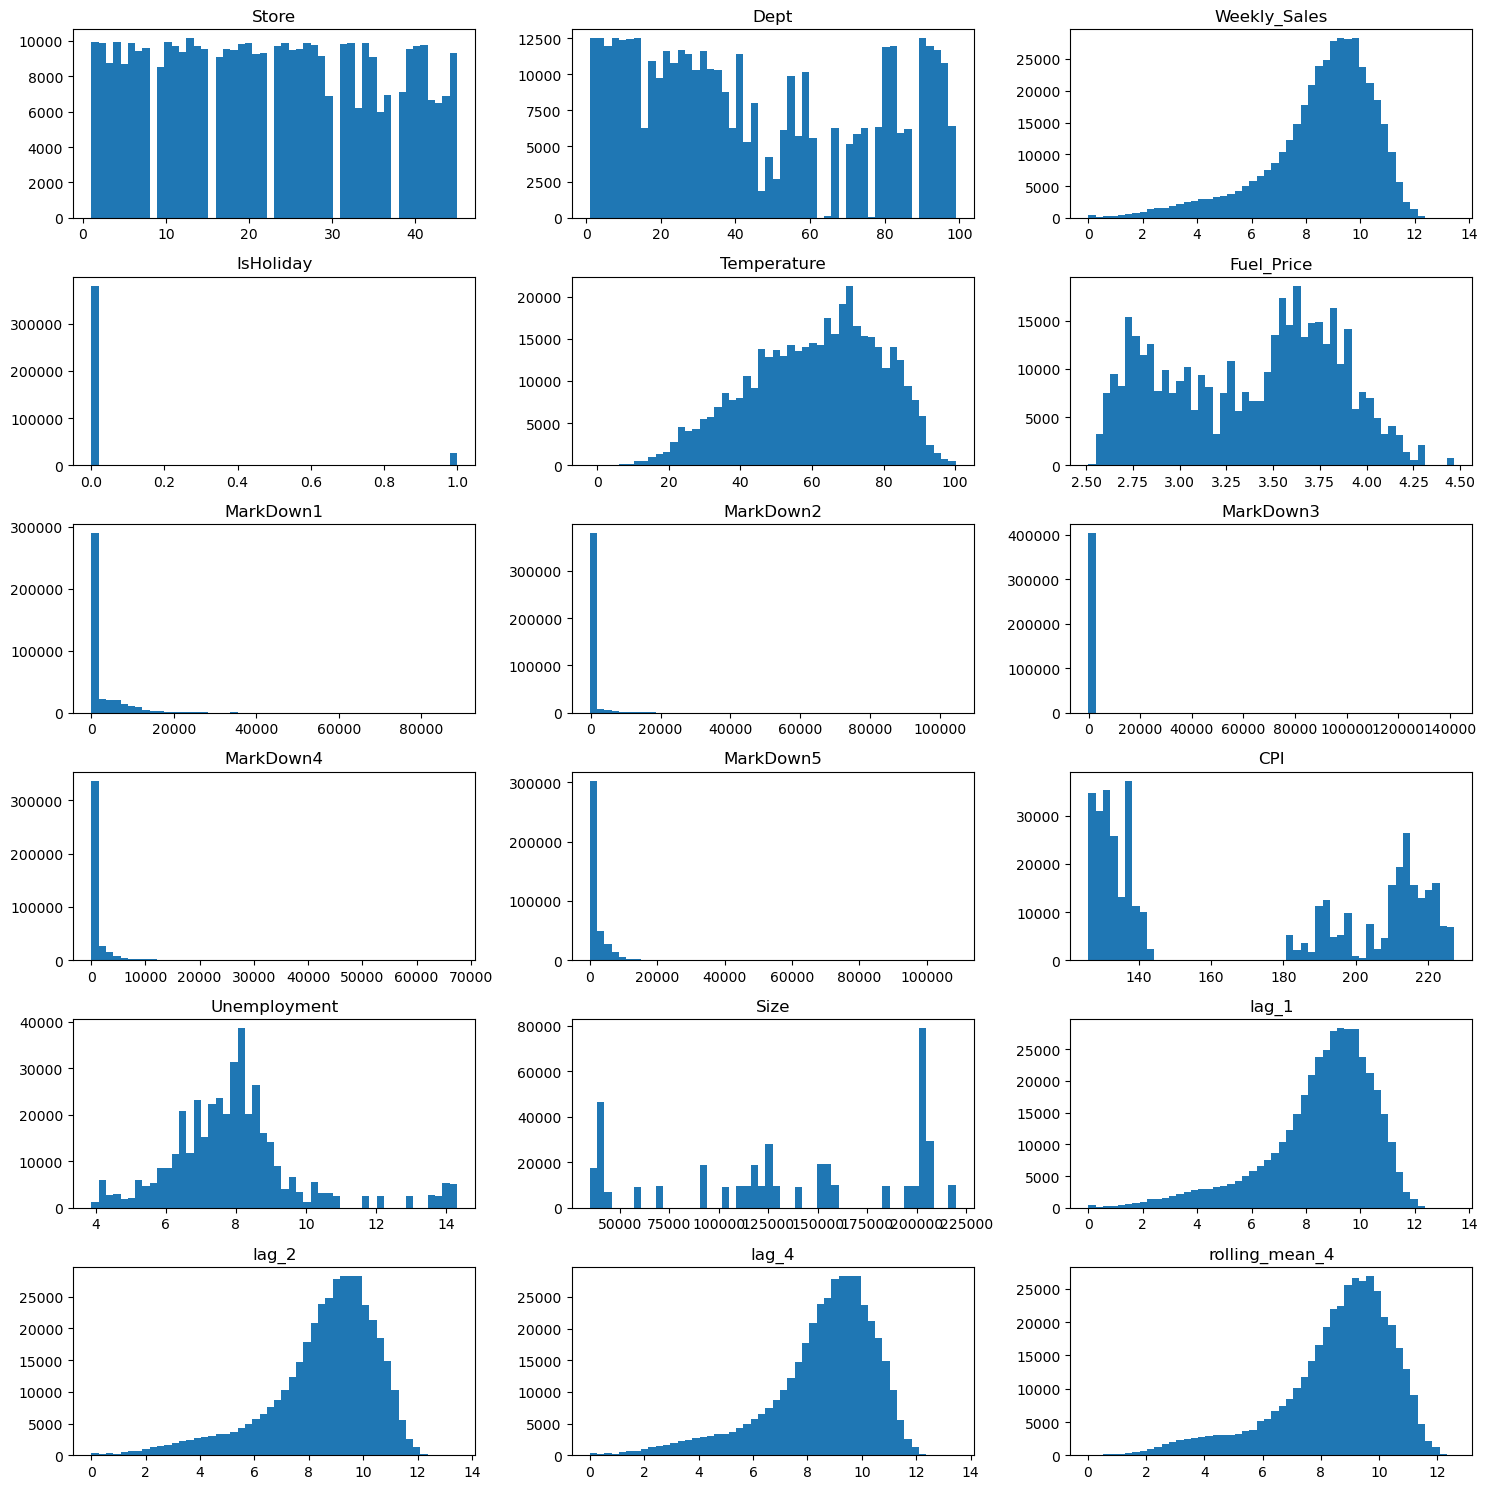

In [48]:
num_cols = df_train_m.select_dtypes(include=["int64","float64"]).columns
n_rows = math.ceil(len(num_cols) / 3)

plt.figure(figsize=(15, 15))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, 3, i)
    plt.hist(df_train_m[col], bins=50)
    plt.title(col)

plt.tight_layout()
plt.show()

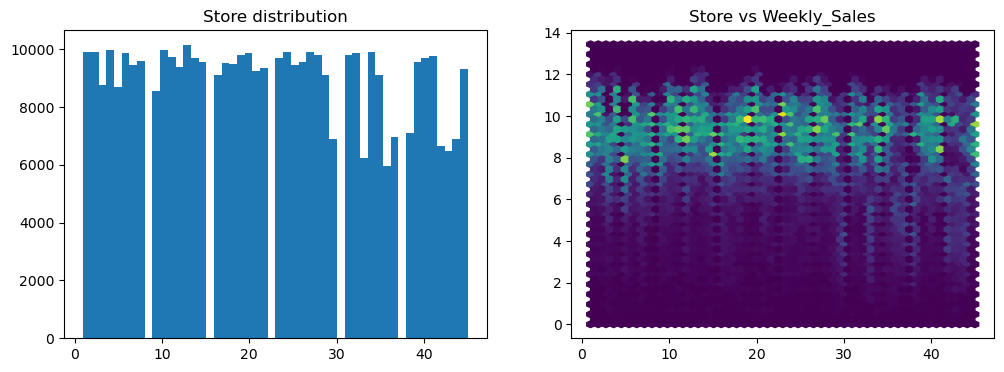

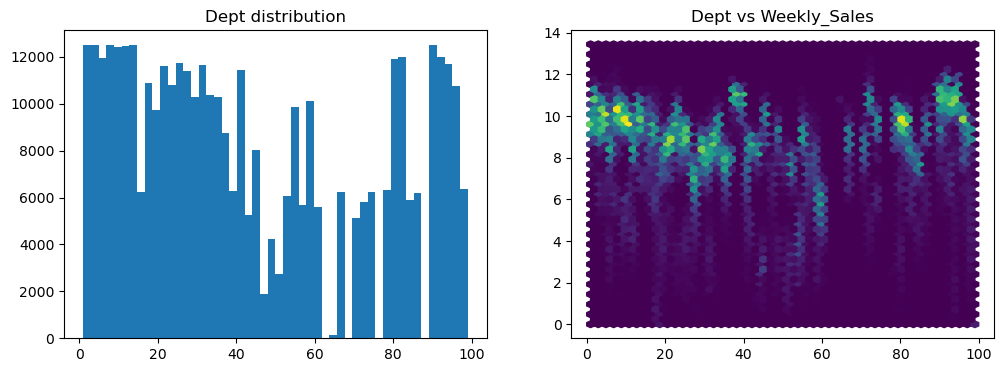

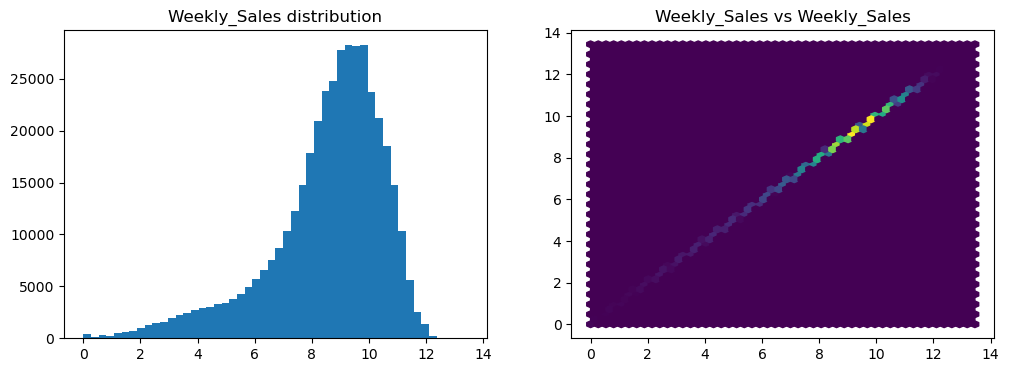

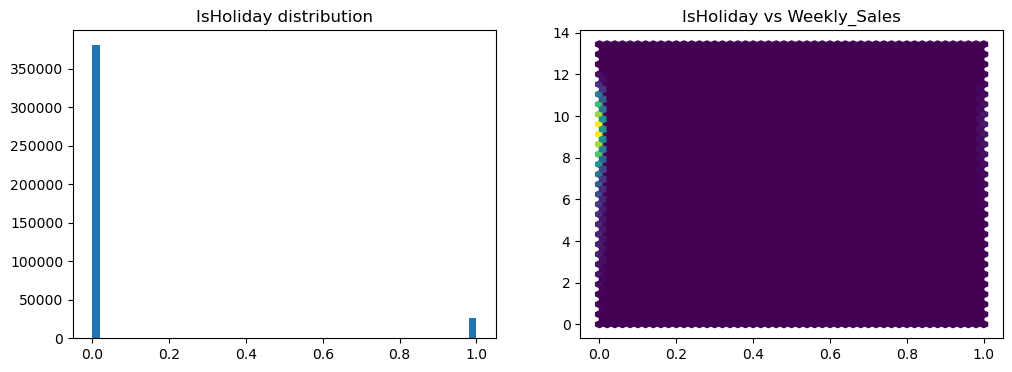

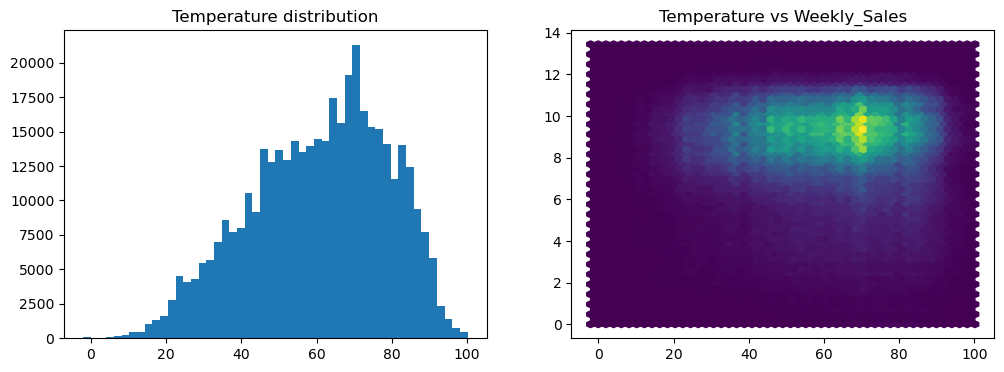

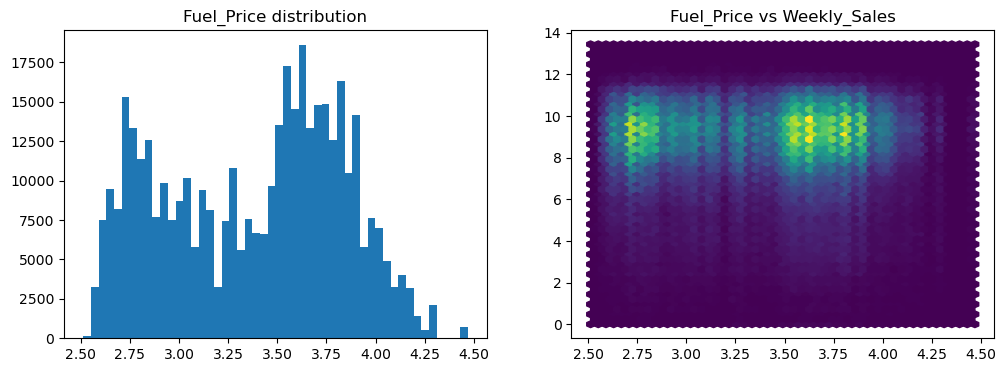

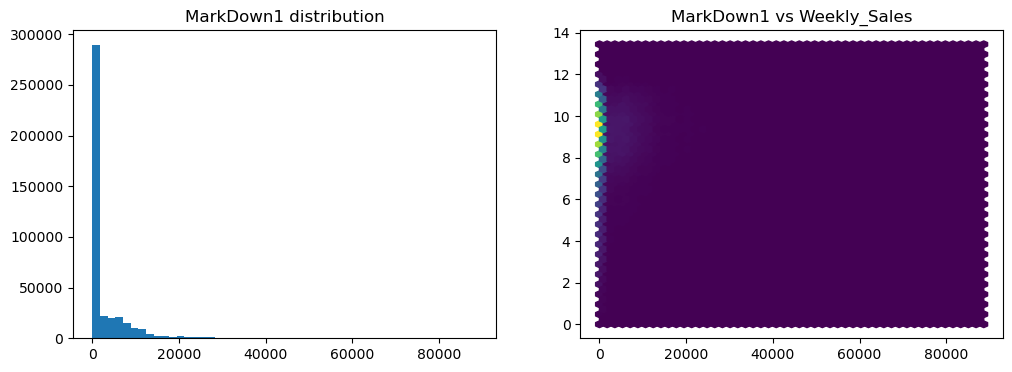

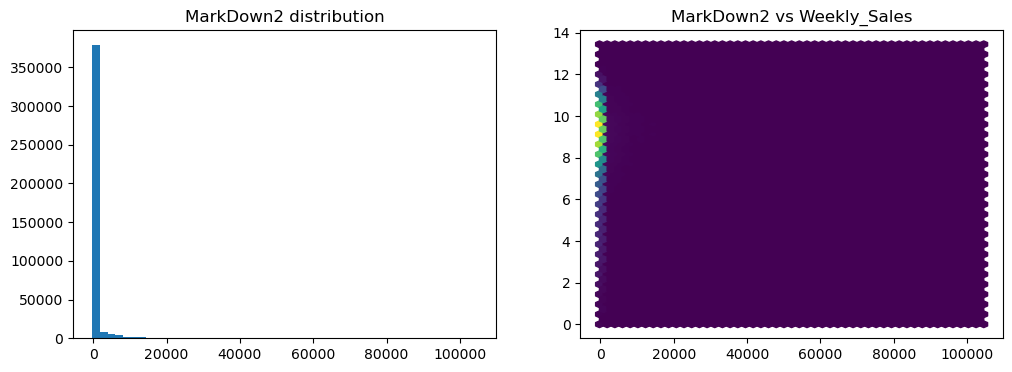

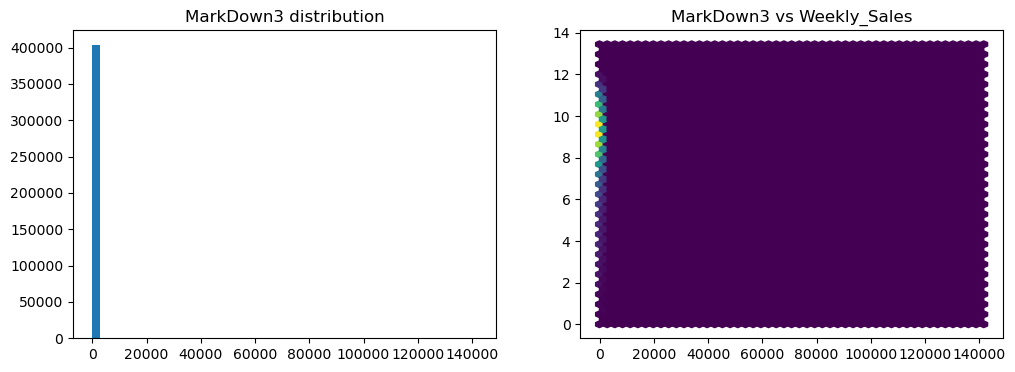

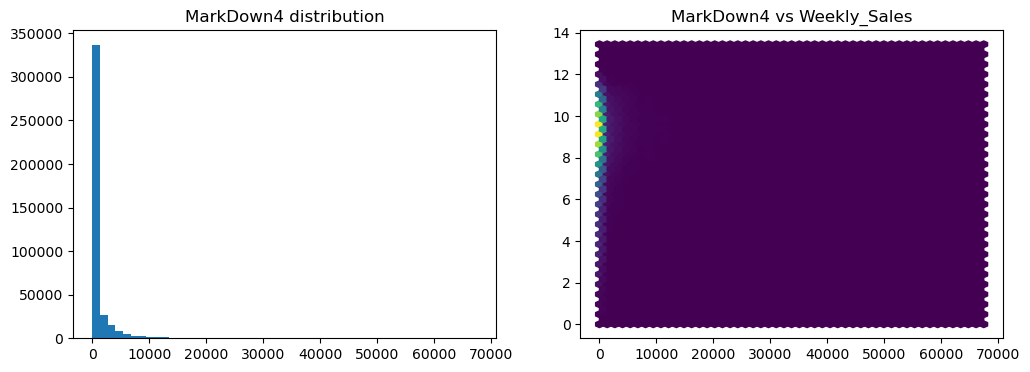

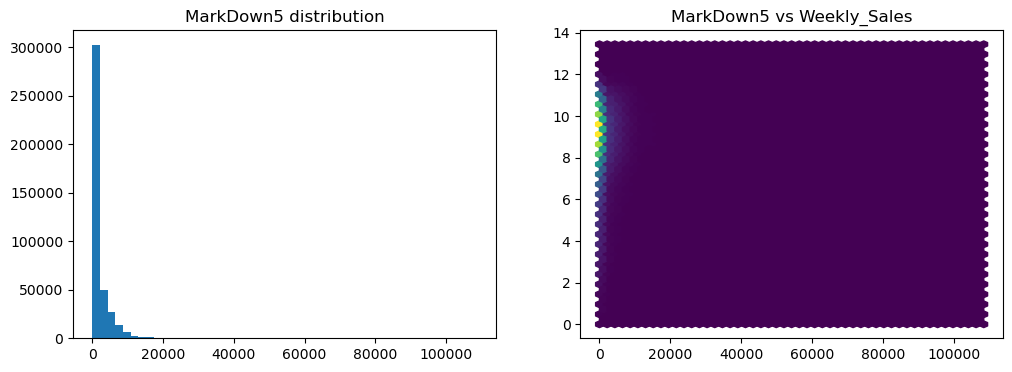

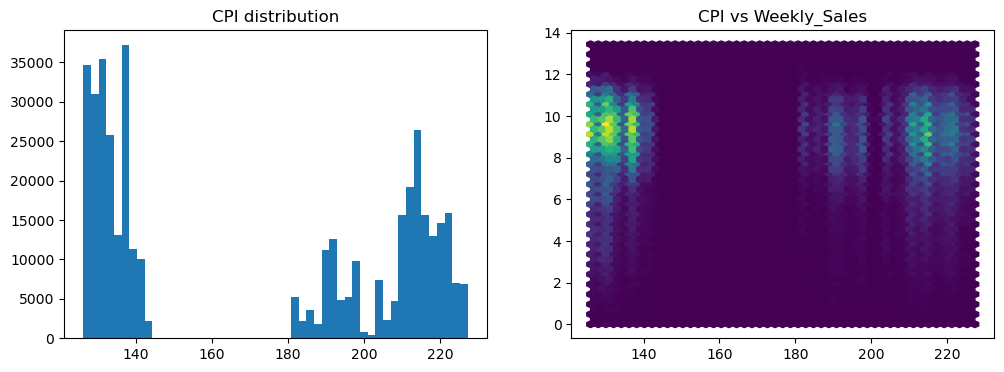

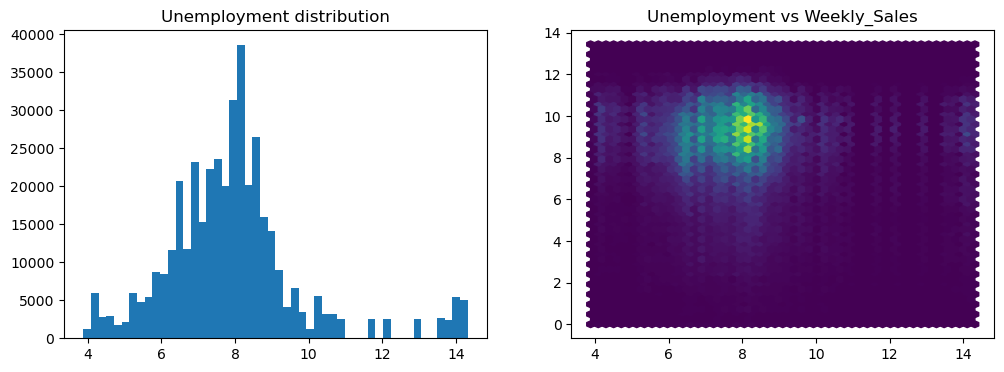

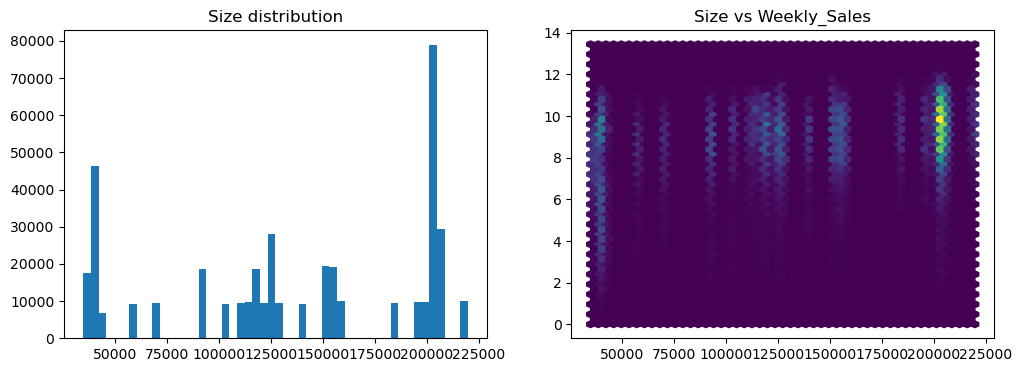

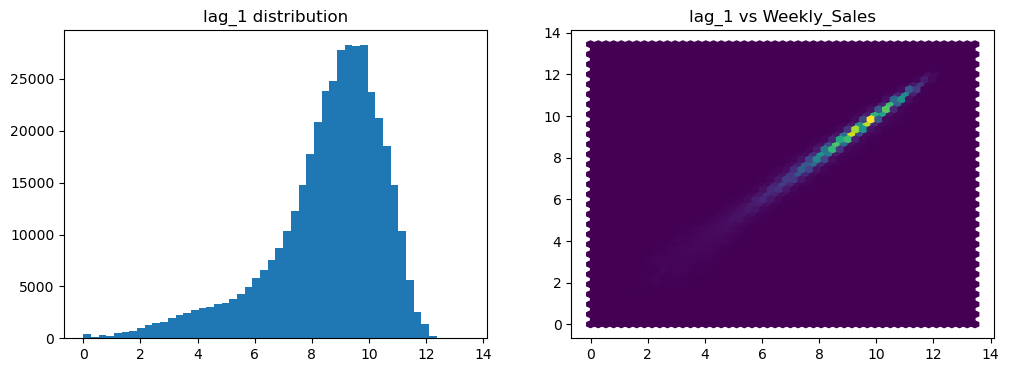

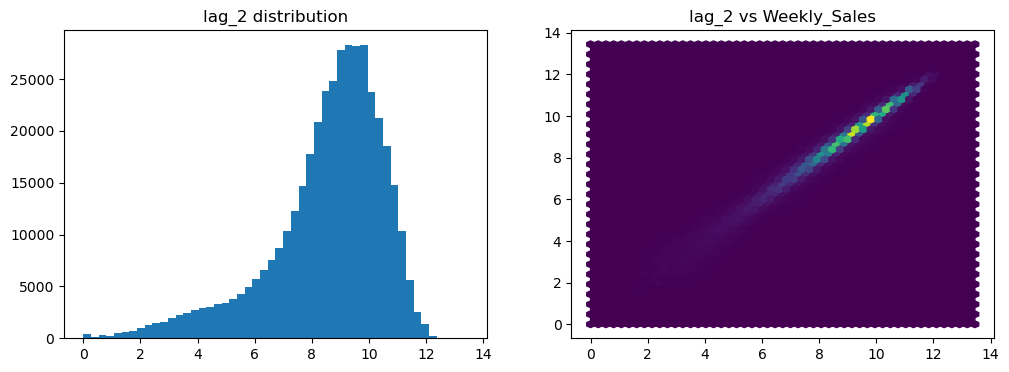

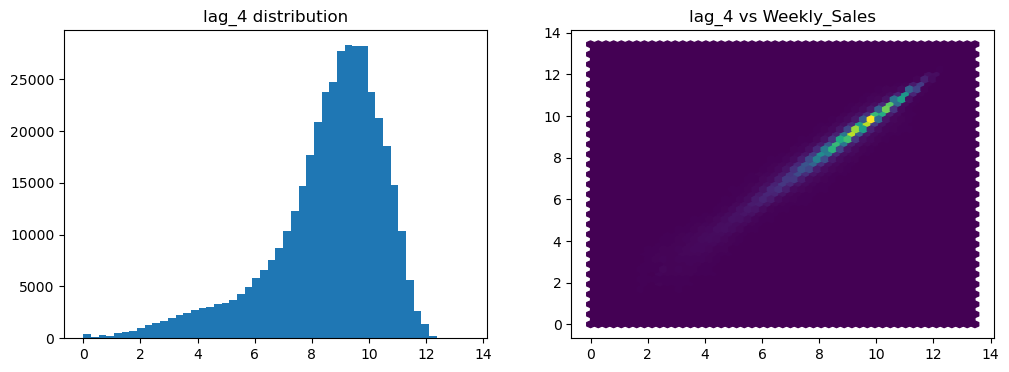

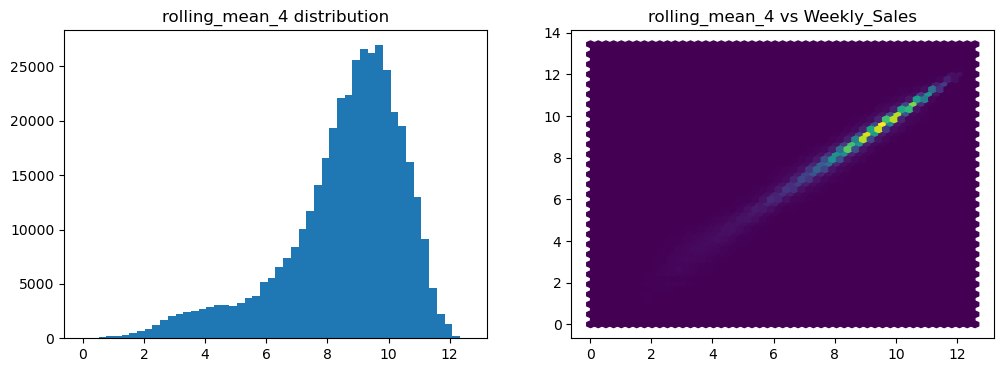

In [53]:
num_cols = df_train_m.select_dtypes(include=["int64","float64"]).columns
for col in num_cols:
    plt.figure(figsize=(12,4))
    
    plt.subplot(1,2,1)
    plt.hist(df_train_m[col], bins=50)
    plt.title(f"{col} distribution")
    
    plt.subplot(1,2,2)
    plt.hexbin(df_train_m[col], df_train_m["Weekly_Sales"], gridsize=50)
    plt.title(f"{col} vs Weekly_Sales")
    
    plt.show()

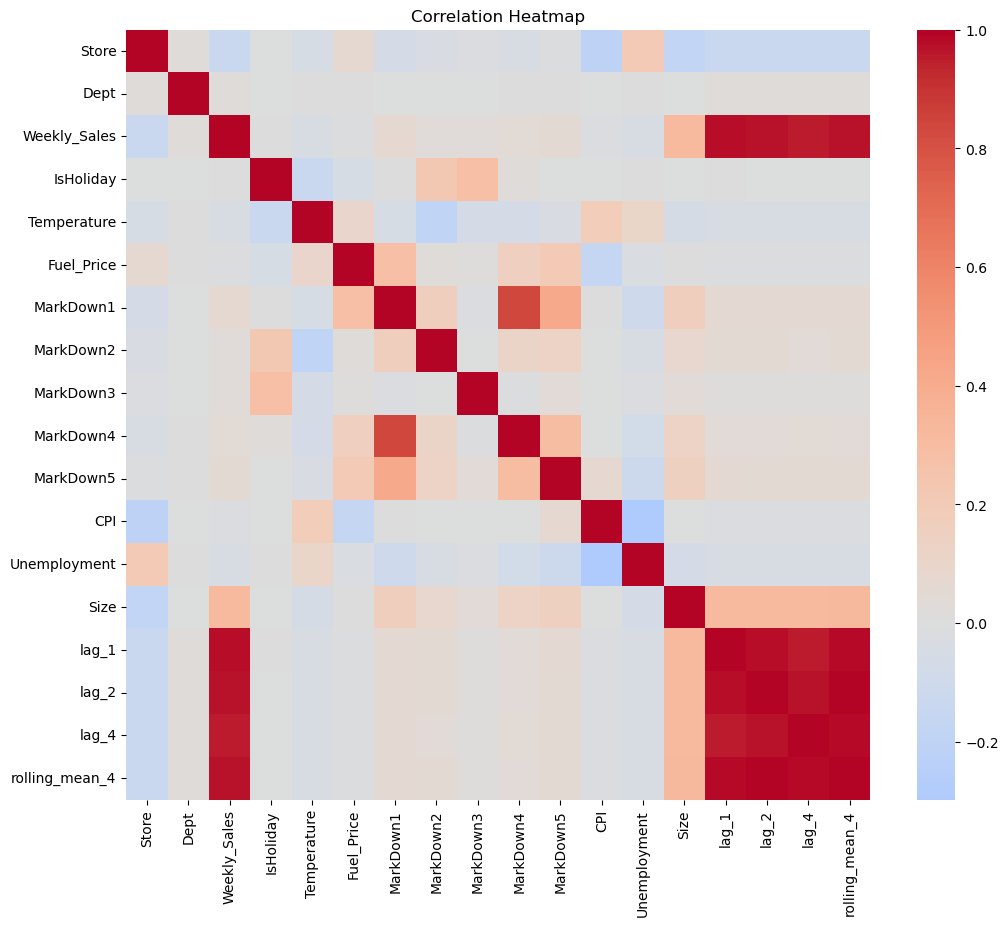

In [55]:
corr = df_train_m[num_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [56]:
df_train_m["Date"].max()

Timestamp('2012-10-26 00:00:00')

In [57]:
df_train_m["Date"].min()

Timestamp('2010-03-05 00:00:00')

In [58]:
split_date = "2012-08-01"

train_df = df_train_m[df_train_m["Date"] < split_date]
valid_df = df_train_m[df_train_m["Date"] >= split_date]

print(train_df.shape, valid_df.shape)

(368801, 20) (38387, 20)


In [60]:
target = "Weekly_Sales"

features = [col for col in df_train_m.columns if col not in ["Weekly_Sales", "Date"]]

X_train = train_df[features]
y_train = train_df[target]

X_valid = valid_df[features]
y_valid = valid_df[target]

In [76]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=-1,
    random_state=37
)

model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="rmse",
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004068 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3480
[LightGBM] [Info] Number of data points in the train set: 368801, number of used features: 18
[LightGBM] [Info] Start training from score 8.549918


LGBMRegressor(learning_rate=0.05, n_estimators=1000, random_state=37)

In [77]:
from sklearn.metrics import mean_squared_error
import numpy as np

preds = model.predict(X_valid)
rmse = np.sqrt(mean_squared_error(y_valid, preds))

real_preds = np.expm1(preds)
real_y = np.expm1(y_valid)
rmse_real = np.sqrt(mean_squared_error(real_y, real_preds))

print("Validation RMSE (log scale):", rmse)
print("Validation RMSE (real scale):", rmse_real)
print("Mean:", np.expm1(y_valid).mean())
print("median:", np.expm1(y_valid).median())
print("Min:", np.expm1(y_valid).min())
print("Max:", np.expm1(y_valid).max())

Validation RMSE (log scale): 0.37315853153531214
Validation RMSE (real scale): 3069.9867012098935
Mean: 15678.879580326671
median: 7486.710000000006
Min: 0.0
Max: 194032.48


In [78]:
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance.head(15))

           feature  importance
1             Dept        4492
14           lag_1        4007
16           lag_4        3197
4       Fuel_Price        2785
15           lag_2        2726
3      Temperature        2413
17  rolling_mean_4        2096
10             CPI        1661
11    Unemployment        1044
7        MarkDown3         875
0            Store         862
6        MarkDown2         862
13            Size         711
8        MarkDown4         607
2        IsHoliday         520


In [79]:
np.mean(np.abs(real_preds - real_y) / (real_y + 1))

np.float64(0.24335856099472566)

In [80]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(real_y, real_preds)
print(mae)

1408.196275448108


In [81]:
param_grid = [
    {"num_leaves": 31, "max_depth": -1, "min_child_samples": 20, "subsample": 0.8, "colsample_bytree": 0.8},
    {"num_leaves": 50, "max_depth": -1, "min_child_samples": 20, "subsample": 0.8, "colsample_bytree": 0.8},
    {"num_leaves": 70, "max_depth": -1, "min_child_samples": 30, "subsample": 0.8, "colsample_bytree": 0.8},
    {"num_leaves": 31, "max_depth": 10, "min_child_samples": 20, "subsample": 0.9, "colsample_bytree": 0.9},
    {"num_leaves": 50, "max_depth": 10, "min_child_samples": 30, "subsample": 0.9, "colsample_bytree": 0.9},
]

results = []

for params in param_grid:
    model = LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        random_state=37,
        **params
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_valid)

    rmse_log = np.sqrt(mean_squared_error(y_valid, preds))

    real_preds = np.expm1(preds)
    real_y = np.expm1(y_valid)
    rmse_real = np.sqrt(mean_squared_error(real_y, real_preds))

    results.append({
        **params,
        "rmse_log": rmse_log,
        "rmse_real": rmse_real
    })

results_df = pd.DataFrame(results).sort_values("rmse_real")
results_df

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005152 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3480
[LightGBM] [Info] Number of data points in the train set: 368801, number of used features: 18
[LightGBM] [Info] Start training from score 8.549918
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004164 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3480
[LightGBM] [Info] Number of data points in the train set: 368801, number of used features: 18
[LightGBM] [Info] Start training from score 8.549918
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003652 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not eno

,num_leaves,max_depth,min_child_samples,subsample,colsample_bytree,rmse_log,rmse_real
1,50,-1,20,0.8,0.8,0.378110,3051.404493
2,70,-1,30,0.8,0.8,0.377519,3058.348291
4,50,10,30,0.9,0.9,0.375150,3060.412395
3,31,10,20,0.9,0.9,0.373429,3069.869279
0,31,-1,20,0.8,0.8,0.375081,3094.594466
